# 🍽️ Food-101 熱量估算系統 — Transfer Learning

**使用前先切換 GPU Runtime：**
上方選單 → `執行階段` → `變更執行階段類型` → 選 `T4 GPU` → 儲存

| 階段 | 說明 | 預估時間（T4 GPU） |
|---|---|---|
| Phase 1 | 凍結 base，訓練分類頭 | ~30 分鐘 |
| Phase 2 | Fine-tune 最後 20 層 | ~20 分鐘 |
| 合計 | | ~50 分鐘 |

## Step 1：安裝套件

In [ ]:
!pip install -q tensorflowjs
print('✅ 安裝完成')

✅ 安裝完成


## Step 2：掛載 Google Drive（儲存模型用）

In [ ]:
import os
OUTPUT_DIR = '/content/Food101_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'✅ 模型將儲存至: {OUTPUT_DIR}（Colab 本機，訓練完記得下載）')

✅ 模型將儲存至: /content/Food101_output（Colab 本機，訓練完記得下載）


## Step 3：確認 GPU

In [ ]:
import tensorflow as tf
import json, numpy as np
from pathlib import Path

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU 可用: {gpus[0].name}')
    # 動態記憶體分配
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print('⚠️  未偵測到 GPU，請確認已切換為 T4 Runtime')

✅ GPU 可用: /physical_device:GPU:0


## Step 4：設定參數

In [ ]:
# ── 訓練參數（可自行調整）──
IMG_SIZE        = 224
BATCH_SIZE      = 64    # GPU 上可用更大的 batch
EPOCHS_PHASE1   = 15    # Phase 1 最多跑幾 epoch（EarlyStopping 會提早停）
EPOCHS_PHASE2   = 10    # Phase 2 fine-tune epochs
LEARNING_RATE   = 1e-3
NUM_CLASSES     = 101
DATA_DIR        = '/content/data'

OUTPUT = Path(OUTPUT_DIR)
print(f'IMG_SIZE={IMG_SIZE}, BATCH={BATCH_SIZE}, Phase1={EPOCHS_PHASE1}ep, Phase2={EPOCHS_PHASE2}ep')

IMG_SIZE=224, BATCH=64, Phase1=15ep, Phase2=10ep


## Step 5：Food-101 熱量資料庫

In [ ]:
FOOD101_CALORIES = {
    "apple_pie":             {"zh": "蘋果派",          "cal": 237, "protein": 2.3,  "carbs": 34.0, "fat": 10.7},
    "baby_back_ribs":        {"zh": "豬肋排",          "cal": 292, "protein": 22.0, "carbs": 2.0,  "fat": 22.0},
    "baklava":               {"zh": "果仁蜜餅",         "cal": 428, "protein": 6.0,  "carbs": 52.0, "fat": 23.0},
    "beef_carpaccio":        {"zh": "牛肉薄片",         "cal": 164, "protein": 18.0, "carbs": 2.0,  "fat": 9.0},
    "beef_tartare":          {"zh": "韃靼牛肉",         "cal": 175, "protein": 18.0, "carbs": 1.0,  "fat": 11.0},
    "beet_salad":            {"zh": "甜菜根沙拉",        "cal": 55,  "protein": 2.0,  "carbs": 12.0, "fat": 0.3},
    "beignets":              {"zh": "法式甜甜圈",        "cal": 366, "protein": 5.0,  "carbs": 45.0, "fat": 19.0},
    "bibimbap":              {"zh": "韓式拌飯",         "cal": 125, "protein": 6.0,  "carbs": 20.0, "fat": 3.0},
    "bread_pudding":         {"zh": "麵包布丁",         "cal": 194, "protein": 5.0,  "carbs": 32.0, "fat": 6.0},
    "breakfast_burrito":     {"zh": "早餐墨西哥捲",      "cal": 218, "protein": 10.0, "carbs": 22.0, "fat": 10.0},
    "bruschetta":            {"zh": "義式烤麵包",        "cal": 198, "protein": 5.0,  "carbs": 30.0, "fat": 6.0},
    "caesar_salad":          {"zh": "凱薩沙拉",         "cal": 120, "protein": 4.0,  "carbs": 8.0,  "fat": 8.0},
    "cannoli":               {"zh": "卡諾里",          "cal": 340, "protein": 8.0,  "carbs": 38.0, "fat": 17.0},
    "caprese_salad":         {"zh": "卡布里沙拉",        "cal": 155, "protein": 10.0, "carbs": 5.0,  "fat": 11.0},
    "carrot_cake":           {"zh": "胡蘿蔔蛋糕",        "cal": 415, "protein": 4.0,  "carbs": 56.0, "fat": 21.0},
    "ceviche":               {"zh": "生魚醃漬",         "cal": 72,  "protein": 11.0, "carbs": 5.0,  "fat": 1.0},
    "cheese_plate":          {"zh": "起司拼盤",         "cal": 350, "protein": 20.0, "carbs": 5.0,  "fat": 28.0},
    "cheesecake":            {"zh": "起司蛋糕",         "cal": 321, "protein": 5.5,  "carbs": 25.0, "fat": 22.0},
    "chicken_curry":         {"zh": "咖哩雞",          "cal": 170, "protein": 15.0, "carbs": 8.0,  "fat": 8.0},
    "chicken_quesadilla":    {"zh": "雞肉墨西哥薄餅",    "cal": 238, "protein": 14.0, "carbs": 22.0, "fat": 11.0},
    "chicken_wings":         {"zh": "雞翅",           "cal": 290, "protein": 27.0, "carbs": 0.0,  "fat": 19.0},
    "chocolate_cake":        {"zh": "巧克力蛋糕",        "cal": 371, "protein": 5.0,  "carbs": 52.0, "fat": 18.0},
    "chocolate_mousse":      {"zh": "巧克力慕斯",        "cal": 235, "protein": 4.0,  "carbs": 28.0, "fat": 12.0},
    "churros":               {"zh": "吉拿棒",          "cal": 376, "protein": 5.0,  "carbs": 50.0, "fat": 18.0},
    "clam_chowder":          {"zh": "蛤蜊巧達湯",        "cal": 101, "protein": 6.0,  "carbs": 11.0, "fat": 3.5},
    "club_sandwich":         {"zh": "總匯三明治",        "cal": 228, "protein": 15.0, "carbs": 22.0, "fat": 9.0},
    "crab_cakes":            {"zh": "蟹肉餅",          "cal": 192, "protein": 17.0, "carbs": 9.0,  "fat": 10.0},
    "creme_brulee":          {"zh": "焦糖布丁",         "cal": 236, "protein": 4.0,  "carbs": 22.0, "fat": 15.0},
    "croque_madame":         {"zh": "法式烤火腿起司蛋",   "cal": 255, "protein": 16.0, "carbs": 18.0, "fat": 14.0},
    "cup_cakes":             {"zh": "杯子蛋糕",         "cal": 370, "protein": 4.0,  "carbs": 52.0, "fat": 17.0},
    "deviled_eggs":          {"zh": "魔鬼蛋",          "cal": 148, "protein": 9.0,  "carbs": 2.0,  "fat": 12.0},
    "donuts":                {"zh": "甜甜圈",          "cal": 452, "protein": 6.0,  "carbs": 51.0, "fat": 25.0},
    "dumplings":             {"zh": "水餃",           "cal": 191, "protein": 8.0,  "carbs": 26.0, "fat": 6.0},
    "edamame":               {"zh": "毛豆",           "cal": 121, "protein": 11.0, "carbs": 10.0, "fat": 5.0},
    "eggs_benedict":         {"zh": "班尼迪克蛋",        "cal": 262, "protein": 12.0, "carbs": 18.0, "fat": 16.0},
    "escargots":             {"zh": "法式蝸牛",         "cal": 90,  "protein": 16.0, "carbs": 2.0,  "fat": 1.4},
    "falafel":               {"zh": "炸鷹嘴豆餅",        "cal": 333, "protein": 13.0, "carbs": 31.0, "fat": 18.0},
    "filet_mignon":          {"zh": "菲力牛排",         "cal": 219, "protein": 26.0, "carbs": 0.0,  "fat": 12.0},
    "fish_and_chips":        {"zh": "炸魚薯條",         "cal": 260, "protein": 12.0, "carbs": 24.0, "fat": 13.0},
    "foie_gras":             {"zh": "鵝肝",           "cal": 462, "protein": 11.0, "carbs": 5.0,  "fat": 44.0},
    "french_fries":          {"zh": "薯條",           "cal": 312, "protein": 3.4,  "carbs": 41.0, "fat": 15.0},
    "french_onion_soup":     {"zh": "法式洋蔥湯",        "cal": 78,  "protein": 4.0,  "carbs": 10.0, "fat": 3.0},
    "french_toast":          {"zh": "法式吐司",         "cal": 229, "protein": 9.0,  "carbs": 27.0, "fat": 10.0},
    "fried_calamari":        {"zh": "炸魷魚",          "cal": 175, "protein": 14.0, "carbs": 12.0, "fat": 8.0},
    "fried_rice":            {"zh": "炒飯",           "cal": 163, "protein": 4.0,  "carbs": 25.0, "fat": 5.0},
    "frozen_yogurt":         {"zh": "冷凍優格",         "cal": 127, "protein": 3.5,  "carbs": 26.0, "fat": 1.5},
    "garlic_bread":          {"zh": "蒜味麵包",         "cal": 350, "protein": 8.0,  "carbs": 45.0, "fat": 16.0},
    "gnocchi":               {"zh": "義式馬鈴薯麵疙瘩",  "cal": 130, "protein": 4.0,  "carbs": 25.0, "fat": 1.5},
    "greek_salad":           {"zh": "希臘沙拉",         "cal": 79,  "protein": 3.0,  "carbs": 7.0,  "fat": 4.5},
    "grilled_cheese_sandwich":{"zh": "烤起司三明治",     "cal": 312, "protein": 13.0, "carbs": 30.0, "fat": 16.0},
    "grilled_salmon":        {"zh": "烤鮭魚",          "cal": 208, "protein": 28.0, "carbs": 0.0,  "fat": 10.0},
    "guacamole":             {"zh": "酪梨醬",          "cal": 157, "protein": 2.0,  "carbs": 9.0,  "fat": 14.0},
    "gyoza":                 {"zh": "煎餃",           "cal": 200, "protein": 8.0,  "carbs": 22.0, "fat": 9.0},
    "hamburger":             {"zh": "漢堡",           "cal": 295, "protein": 17.0, "carbs": 24.0, "fat": 13.0},
    "hot_and_sour_soup":     {"zh": "酸辣湯",          "cal": 45,  "protein": 4.0,  "carbs": 5.0,  "fat": 1.0},
    "hot_dog":               {"zh": "熱狗",           "cal": 290, "protein": 11.0, "carbs": 23.0, "fat": 17.0},
    "huevos_rancheros":      {"zh": "墨西哥蛋",         "cal": 175, "protein": 10.0, "carbs": 14.0, "fat": 9.0},
    "hummus":                {"zh": "鷹嘴豆泥",         "cal": 177, "protein": 8.0,  "carbs": 20.0, "fat": 8.0},
    "ice_cream":             {"zh": "冰淇淋",          "cal": 207, "protein": 3.5,  "carbs": 24.0, "fat": 11.0},
    "lasagna":               {"zh": "千層麵",          "cal": 135, "protein": 8.0,  "carbs": 13.0, "fat": 6.0},
    "lobster_bisque":        {"zh": "龍蝦濃湯",         "cal": 120, "protein": 8.0,  "carbs": 10.0, "fat": 6.0},
    "lobster_roll_sandwich": {"zh": "龍蝦三明治",        "cal": 208, "protein": 15.0, "carbs": 20.0, "fat": 8.0},
    "macaroni_and_cheese":   {"zh": "起司通心粉",        "cal": 164, "protein": 7.0,  "carbs": 20.0, "fat": 6.0},
    "macarons":              {"zh": "馬卡龍",          "cal": 407, "protein": 7.0,  "carbs": 62.0, "fat": 15.0},
    "miso_soup":             {"zh": "味噌湯",          "cal": 40,  "protein": 3.0,  "carbs": 5.0,  "fat": 1.0},
    "mussels":               {"zh": "淡菜",           "cal": 86,  "protein": 12.0, "carbs": 4.0,  "fat": 2.0},
    "nachos":                {"zh": "墨西哥玉米片",      "cal": 306, "protein": 8.0,  "carbs": 35.0, "fat": 15.0},
    "omelette":              {"zh": "歐姆蛋",          "cal": 154, "protein": 11.0, "carbs": 2.0,  "fat": 12.0},
    "onion_rings":           {"zh": "洋蔥圈",          "cal": 411, "protein": 5.0,  "carbs": 44.0, "fat": 24.0},
    "oysters":               {"zh": "生蠔",           "cal": 68,  "protein": 8.0,  "carbs": 4.0,  "fat": 2.0},
    "pad_thai":              {"zh": "泰式炒河粉",        "cal": 181, "protein": 9.0,  "carbs": 24.0, "fat": 6.0},
    "paella":                {"zh": "西班牙海鮮飯",      "cal": 153, "protein": 10.0, "carbs": 20.0, "fat": 4.0},
    "pancakes":              {"zh": "鬆餅",           "cal": 227, "protein": 6.0,  "carbs": 35.0, "fat": 8.0},
    "panna_cotta":           {"zh": "奶酪",           "cal": 220, "protein": 3.0,  "carbs": 22.0, "fat": 14.0},
    "peking_duck":           {"zh": "北京烤鴨",         "cal": 342, "protein": 29.0, "carbs": 5.0,  "fat": 23.0},
    "pho":                   {"zh": "越南河粉",         "cal": 90,  "protein": 7.0,  "carbs": 12.0, "fat": 2.0},
    "pizza":                 {"zh": "披薩",           "cal": 266, "protein": 11.0, "carbs": 33.0, "fat": 10.0},
    "pork_chop":             {"zh": "豬排",           "cal": 231, "protein": 26.0, "carbs": 0.0,  "fat": 13.0},
    "poutine":               {"zh": "加拿大肉汁薯條",    "cal": 280, "protein": 9.0,  "carbs": 32.0, "fat": 14.0},
    "prime_rib":             {"zh": "主肋排",          "cal": 263, "protein": 24.0, "carbs": 0.0,  "fat": 18.0},
    "pulled_pork_sandwich":  {"zh": "手撕豬肉堡",        "cal": 263, "protein": 18.0, "carbs": 24.0, "fat": 10.0},
    "ramen":                 {"zh": "拉麵",           "cal": 112, "protein": 7.0,  "carbs": 14.0, "fat": 3.0},
    "ravioli":               {"zh": "義式餃子",         "cal": 187, "protein": 9.0,  "carbs": 25.0, "fat": 6.0},
    "red_velvet_cake":       {"zh": "紅絲絨蛋糕",        "cal": 415, "protein": 4.5,  "carbs": 56.0, "fat": 20.0},
    "risotto":               {"zh": "燉飯",           "cal": 148, "protein": 5.0,  "carbs": 26.0, "fat": 3.0},
    "samosa":                {"zh": "三角炸餃",         "cal": 308, "protein": 6.0,  "carbs": 32.0, "fat": 18.0},
    "sashimi":               {"zh": "生魚片",          "cal": 130, "protein": 22.0, "carbs": 0.0,  "fat": 4.0},
    "scallops":              {"zh": "干貝",           "cal": 111, "protein": 20.0, "carbs": 5.0,  "fat": 1.0},
    "seaweed_salad":         {"zh": "海藻沙拉",         "cal": 45,  "protein": 2.0,  "carbs": 8.0,  "fat": 0.5},
    "shrimp_and_grits":      {"zh": "蝦仁玉米粥",        "cal": 175, "protein": 14.0, "carbs": 16.0, "fat": 6.0},
    "spaghetti_bolognese":   {"zh": "肉醬義大利麵",      "cal": 147, "protein": 9.0,  "carbs": 18.0, "fat": 4.0},
    "spaghetti_carbonara":   {"zh": "培根蛋黃義麵",      "cal": 188, "protein": 9.0,  "carbs": 22.0, "fat": 7.0},
    "spring_rolls":          {"zh": "春捲",           "cal": 265, "protein": 6.0,  "carbs": 30.0, "fat": 14.0},
    "steak":                 {"zh": "牛排",           "cal": 271, "protein": 26.0, "carbs": 0.0,  "fat": 18.0},
    "strawberry_shortcake":  {"zh": "草莓蛋糕",         "cal": 328, "protein": 4.0,  "carbs": 48.0, "fat": 14.0},
    "sushi":                 {"zh": "壽司",           "cal": 143, "protein": 9.0,  "carbs": 24.0, "fat": 2.0},
    "tacos":                 {"zh": "塔可",           "cal": 226, "protein": 12.0, "carbs": 22.0, "fat": 10.0},
    "takoyaki":              {"zh": "章魚燒",          "cal": 200, "protein": 8.0,  "carbs": 24.0, "fat": 8.0},
    "tiramisu":              {"zh": "提拉米蘇",         "cal": 240, "protein": 6.0,  "carbs": 28.0, "fat": 12.0},
    "tuna_tartare":          {"zh": "鮪魚韃靼",         "cal": 108, "protein": 15.0, "carbs": 3.0,  "fat": 4.0},
    "waffles":               {"zh": "格子鬆餅",         "cal": 291, "protein": 8.0,  "carbs": 37.0, "fat": 13.0},
}
CLASS_NAMES = sorted(FOOD101_CALORIES.keys())
print(f'✅ 資料庫載入完成，共 {len(CLASS_NAMES)} 種食物')

✅ 資料庫載入完成，共 101 種食物


## Step 6：載入 Food-101 資料集

In [ ]:
# 直接下載 Food-101 官方資料集（繞過 tensorflow-datasets）
!wget -q --show-progress http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
!tar xzf food-101.tar.gz -C /content/
print('✅ 解壓完成')

import tensorflow as tf

FOOD101_DIR = '/content/food-101/images'

# 建立完整 dataset
ds_full = tf.keras.utils.image_dataset_from_directory(
    FOOD101_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    seed=42,
    shuffle=True,
)

# 取得 class 名稱（會按資料夾字母排序，與 CLASS_NAMES 一致）
class_names_from_dir = ds_full.class_names
print(f'✅ 偵測到 {len(class_names_from_dir)} 類食物')

# 80% train / 20% val
AUTOTUNE = tf.data.AUTOTUNE
total_batches = ds_full.cardinality().numpy()
train_size = int(total_batches * 0.8)

ds_train = (ds_full.take(train_size)
            .map(lambda x, y: (tf.cast(x, tf.float32), y))
            .prefetch(AUTOTUNE))

ds_val = (ds_full.skip(train_size)
          .map(lambda x, y: (tf.cast(x, tf.float32), y))
          .prefetch(AUTOTUNE))

print(f'✅ 訓練批次: {train_size}，驗證批次: {total_batches - train_size}')

food-101.tar.gz     100%[===================>]   4.65G  22.7MB/s    in 5m 59s  
✅ 解壓完成
Found 101000 files belonging to 101 classes.
✅ 偵測到 101 類食物
✅ 訓練批次: 1263，驗證批次: 316


## Step 7：Phase 1 — 訓練分類頭（Base 凍結）

In [ ]:
from tensorflow.keras import layers, Model

def build_model(finetune=False):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = finetune
    if finetune:
        for layer in base.layers[:-20]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=finetune)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs, outputs)

# ── Phase 1 ──
model = build_model(finetune=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_acc')]
)

ckpt_p1 = str(OUTPUT / 'best_phase1.keras')
callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint(ckpt_p1, save_best_only=True,
                                        monitor='val_accuracy', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                      restore_best_weights=True),
    tf.keras.callbacks.TensorBoard(log_dir=str(OUTPUT / 'logs/phase1')),
]

print('開始 Phase 1 訓練...')
history1 = model.fit(
    ds_train, validation_data=ds_val,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_p1,
)
print(f'Phase 1 完成，最佳 val_accuracy: {max(history1.history["val_accuracy"]):.4f}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
開始 Phase 1 訓練...
Epoch 1/15
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.4313 - loss: 2.4338 - top5_acc: 0.6842
Epoch 1: val_accuracy improved from None to 0.64473, saving model to /content/Food101_output/best_phase1.keras

Epoch 1: finished saving model to /content/Food101_output/best_phase1.keras
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 410s 299ms/step - accuracy: 0.5085 - loss: 1.9999 - top5_acc: 0.7699 - val_accuracy: 0.6447 - val_loss: 1.3582 - val_top5_acc: 0.8729 - learning_rate: 0.0010
Epoch 2/15
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6000 - loss: 1.5378 - top5_acc: 0.8476
Epoch 2: val_accuracy improved from 0.64473 to 0.65986, saving model to /content/Food101_output/best_phase1.keras

Epoch 2: finished saving model to /content/Food101_output/best_phase1.keras
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 290s 229ms/step - accuracy: 0.6023 - loss: 1.5163 - top5_acc: 0.8514 - val_accuracy: 0.6599 - val_loss: 1.2902 - va

## Step 8：Phase 2 — Fine-tune（解凍最後 20 層）

In [ ]:
model2 = build_model(finetune=True)
model2.load_weights(ckpt_p1)
model2.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE * 0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_acc')]
)

ckpt_p2 = str(OUTPUT / 'best_final.keras')
callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint(ckpt_p2, save_best_only=True,
                                        monitor='val_accuracy', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=3, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                                      restore_best_weights=True),
    tf.keras.callbacks.TensorBoard(log_dir=str(OUTPUT / 'logs/phase2')),
]

print('開始 Phase 2 Fine-tune...')
history2 = model2.fit(
    ds_train, validation_data=ds_val,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_p2,
)

best_acc  = max(history1.history['val_accuracy'] + history2.history['val_accuracy'])
best_top5 = max(history1.history['val_top5_acc'] + history2.history['val_top5_acc'])
print(f'\n🎉 訓練完成！')
print(f'   Best Val Accuracy : {best_acc:.4f} ({best_acc*100:.1f}%)')
print(f'   Best Val Top-5    : {best_top5:.4f} ({best_top5*100:.1f}%)')

開始 Phase 2 Fine-tune...
Epoch 1/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6334 - loss: 1.3677 - top5_acc: 0.8732
Epoch 1: val_accuracy improved from None to 0.70032, saving model to /content/Food101_output/best_final.keras

Epoch 1: finished saving model to /content/Food101_output/best_final.keras
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 316s 228ms/step - accuracy: 0.6897 - loss: 1.1251 - top5_acc: 0.9106 - val_accuracy: 0.7003 - val_loss: 1.2043 - val_top5_acc: 0.8991 - learning_rate: 1.0000e-04
Epoch 2/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7442 - loss: 0.9038 - top5_acc: 0.9398
Epoch 2: val_accuracy improved from 0.70032 to 0.71296, saving model to /content/Food101_output/best_final.keras

Epoch 2: finished saving model to /content/Food101_output/best_final.keras
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 277s 219ms/step - accuracy: 0.7533 - loss: 0.8610 - top5_acc: 0.9446 - val_accuracy: 0.7130 - val_loss: 1.1651 - val_top5_acc: 0.9040 - learning_rate: 1.0000e-

## Step 9：儲存模型 + 轉換 TF.js

In [ ]:
import subprocess

# 儲存 Keras 格式
keras_path = str(OUTPUT / 'food101_model.keras')
model2.save(keras_path)
print(f'✅ Keras 模型: {keras_path}')

# 儲存 SavedModel 格式
saved_model_path = str(OUTPUT / 'saved_model')
model2.export(saved_model_path)
print(f'✅ SavedModel: {saved_model_path}')

# 儲存熱量資料庫
calorie_json = str(OUTPUT / 'calorie_db.json')
with open(calorie_json, 'w', encoding='utf-8') as f:
    json.dump({"class_names": CLASS_NAMES, "calories": FOOD101_CALORIES},
              f, ensure_ascii=False, indent=2)
print(f'✅ 熱量資料庫: {calorie_json}')

# 轉換為 TF.js
tfjs_path = str(OUTPUT / 'tfjs_model')
result = subprocess.run([
    'tensorflowjs_converter',
    '--input_format=tf_saved_model',
    '--output_format=tfjs_graph_model',
    '--signature_name=serving_default',
    '--saved_model_tags=serve',
    saved_model_path, tfjs_path
], capture_output=True, text=True)

if result.returncode == 0:
    print(f'✅ TF.js 模型: {tfjs_path}')
else:
    print(f'⚠️  TF.js 轉換失敗:\n{result.stderr}')

✅ Keras 模型: /content/Food101_output/food101_model.keras
Saved artifact at '/content/Food101_output/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_484')
Output Type:
  TensorSpec(shape=(None, 101), dtype=tf.float32, name=None)
Captures:
  138952298319888: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138952298318736: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138955283682064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952400918800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952400919376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952400918224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952400914960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952400913232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952400918992: TensorSpec(shape=(), dtype=tf.resource

## Step 10：下載模型到本機

模型已儲存在 Google Drive `Food101_output/` 資料夾中。

如果需要直接下載到電腦，執行下方 cell：

In [ ]:
# 打包 TF.js 模型為 zip 下載
import shutil
from google.colab import files

zip_path = '/content/tfjs_model.zip'
shutil.make_archive('/content/tfjs_model', 'zip', tfjs_path)
files.download(zip_path)
print('✅ 下載完成，解壓後放進 food_calorie_estimator.html 同資料夾')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 下載完成，解壓後放進 food_calorie_estimator.html 同資料夾


## Step 11（選用）：測試單張圖片

In [ ]:
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()  # 上傳一張食物圖片

for fname, data in uploaded.items():
    img = Image.open(io.BytesIO(data)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    x = np.array(img, dtype=np.float32)[np.newaxis]
    preds = model2.predict(x, verbose=0)[0]
    top5 = np.argsort(preds)[::-1][:5]

    print(f'\n🍽️  {fname} 推理結果:')
    print('─' * 50)
    for i, idx in enumerate(top5):
        name = CLASS_NAMES[idx]
        info = FOOD101_CALORIES[name]
        print(f'  {i+1}. {name} ({info["zh"]})  {preds[idx]*100:.1f}%  →  {info["cal"]} kcal/100g')
    best = FOOD101_CALORIES[CLASS_NAMES[top5[0]]]
    print(f'\n  📊 估算（150g）: {round(best["cal"]*1.5)} kcal')

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import tensorflow as tf
import tensorflowjs as tfjs

# 載入模型
print('載入模型...')
model = tf.keras.models.load_model(str(OUTPUT / 'best_final.keras'))

# 直接轉換（不需要經過 SavedModel）
tfjs_out = str(OUTPUT / 'tfjs_model')
print('轉換為 TF.js 格式...')
tfjs.converters.save_keras_model(model, tfjs_out)
print(f'✅ 轉換完成：{tfjs_out}')

# 確認檔案
import os
for f in os.listdir(tfjs_out):
    size = os.path.getsize(os.path.join(tfjs_out, f)) / 1024 / 1024
    print(f'  {f}  ({size:.1f} MB)')

載入模型...


轉換為 TF.js 格式...
failed to lookup keras version from the file,
    this is likely a weight only file
weight normalization_1/count with shape () and dtype int64 was auto converted to the type int32
✅ 轉換完成：/content/Food101_output/tfjs_model
  group1-shard4of5.bin  (4.0 MB)
  group1-shard1of5.bin  (4.0 MB)
  group1-shard3of5.bin  (4.0 MB)
  group1-shard2of5.bin  (4.0 MB)
  model.json  (0.2 MB)
  group1-shard5of5.bin  (2.2 MB)


In [ ]:
import tensorflow as tf
from google.colab import files

original = tf.keras.models.load_model('/content/Food101_output/best_final.keras')

# TFLite converter 自動移除 Dropout，解決 seed generator 問題
converter = tf.lite.TFLiteConverter.from_keras_model(original)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # float16，縮小一半
tflite_model = converter.convert()

with open('/content/food101.tflite', 'wb') as f:
    f.write(tflite_model)

print(f'大小: {len(tflite_model)/1024/1024:.1f} MB')
files.download('/content/food101.tflite')

Saved artifact at '/tmp/tmp6q7wp7h0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 101), dtype=tf.float32, name=None)
Captures:
  138945974637904: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138945974643088: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138952300839184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952300839376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952300840336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952300841104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952300841680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952300841872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952300839760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138952300841296: TensorSpec(shape=(), dtype=tf.resource, name=N

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

圖表已成功儲存為 'training_metrics.png'


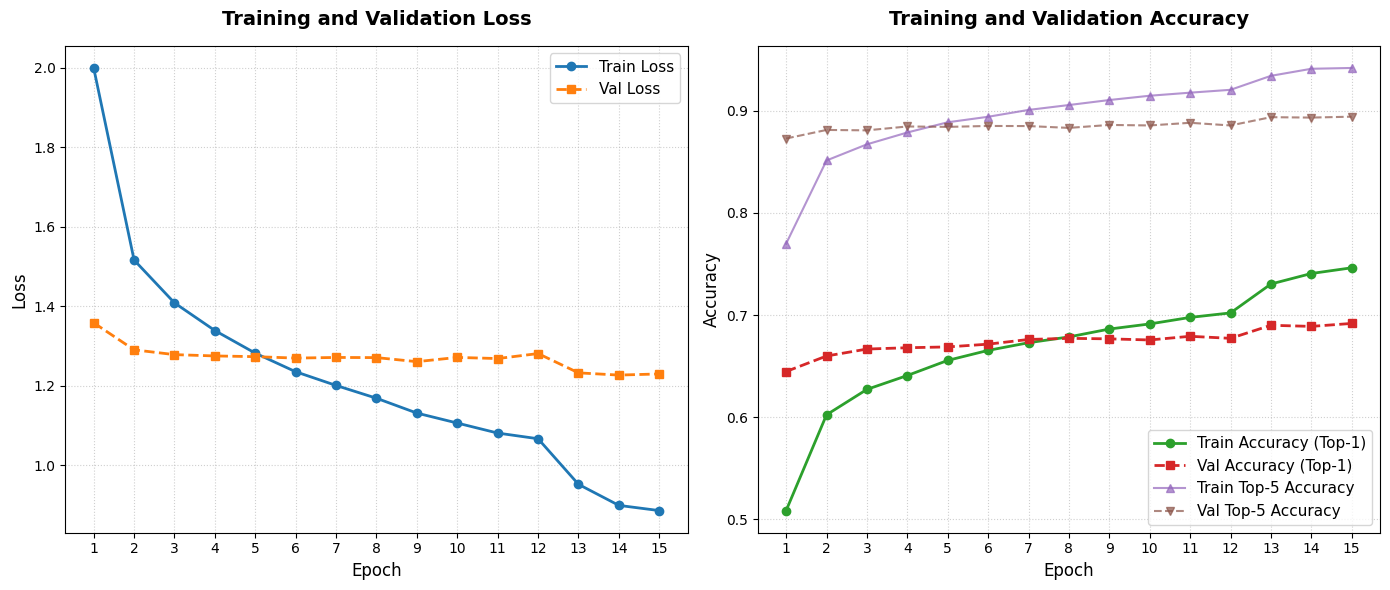

In [ ]:
import matplotlib.pyplot as plt

# 1. 準備從日誌中提取的數據
epochs = list(range(1, 16))

# 損失函數數據
loss = [1.9999, 1.5163, 1.4084, 1.3387, 1.2818, 1.2350, 1.2005, 1.1683, 1.1309, 1.1058, 1.0806, 1.0663, 0.9515, 0.8985, 0.8854]
val_loss = [1.3582, 1.2902, 1.2781, 1.2748, 1.2730, 1.2694, 1.2710, 1.2706, 1.2604, 1.2711, 1.2682, 1.2808, 1.2322, 1.2266, 1.2295]

# 準確率數據 (Top-1)
accuracy = [0.5085, 0.6023, 0.6272, 0.6408, 0.6556, 0.6654, 0.6729, 0.6786, 0.6863, 0.6913, 0.6977, 0.7021, 0.7304, 0.7407, 0.7463]
val_accuracy = [0.6447, 0.6599, 0.6667, 0.6680, 0.6688, 0.6715, 0.6761, 0.6772, 0.6767, 0.6756, 0.6792, 0.6772, 0.6900, 0.6889, 0.6918]

# Top-5 準確率數據
top5_acc = [0.7699, 0.8514, 0.8672, 0.8788, 0.8888, 0.8942, 0.9009, 0.9057, 0.9106, 0.9148, 0.9178, 0.9206, 0.9343, 0.9412, 0.9420]
val_top5_acc = [0.8729, 0.8813, 0.8809, 0.8847, 0.8843, 0.8852, 0.8851, 0.8833, 0.8862, 0.8857, 0.8883, 0.8857, 0.8938, 0.8934, 0.8943]

# 2. 建立畫布與子圖 (1列2欄)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 繪製左圖：Loss 趨勢
ax1.plot(epochs, loss, 'o-', label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, val_loss, 's--', label='Val Loss', color='#ff7f0e', linewidth=2)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=11, loc='upper right')

# 繪製右圖：Accuracy 趨勢
ax2.plot(epochs, accuracy, 'o-', label='Train Accuracy (Top-1)', color='#2ca02c', linewidth=2)
ax2.plot(epochs, val_accuracy, 's--', label='Val Accuracy (Top-1)', color='#d62728', linewidth=2)
ax2.plot(epochs, top5_acc, '^-', label='Train Top-5 Accuracy', color='#9467bd', linewidth=1.5, alpha=0.7)
ax2.plot(epochs, val_top5_acc, 'v--', label='Val Top-5 Accuracy', color='#8c564b', linewidth=1.5, alpha=0.7)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xticks(epochs)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=11, loc='lower right')

# 3. 自動調整版面並儲存
plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300)
print("圖表已成功儲存為 'training_metrics.png'")

圖表已成功儲存為 'fine_tune_metrics.png'


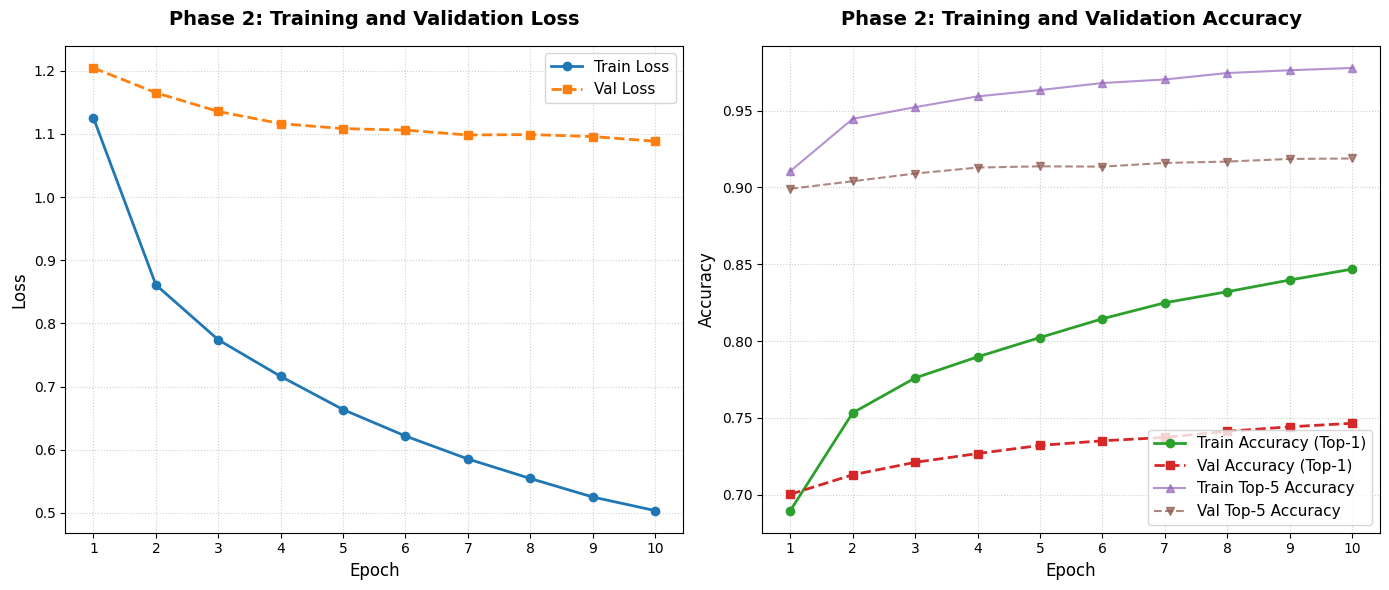

In [ ]:
import matplotlib.pyplot as plt

# 1. 準備從 Phase 2 日誌中提取的數據（共 10 個 Epoch）
epochs = list(range(1, 11))

# 損失函數數據
loss = [1.1251, 0.8610, 0.7740, 0.7161, 0.6636, 0.6217, 0.5854, 0.5545, 0.5252, 0.5037]
val_loss = [1.2043, 1.1651, 1.1354, 1.1162, 1.1083, 1.1059, 1.0982, 1.0989, 1.0957, 1.0883]

# Top-1 準確率數據
accuracy = [0.6897, 0.7533, 0.7760, 0.7897, 0.8023, 0.8145, 0.8249, 0.8321, 0.8397, 0.8468]
val_accuracy = [0.7003, 0.7130, 0.7211, 0.7268, 0.7321, 0.7351, 0.7373, 0.7413, 0.7442, 0.7465]

# Top-5 準確率數據
top5_acc = [0.9106, 0.9446, 0.9522, 0.9592, 0.9633, 0.9679, 0.9702, 0.9744, 0.9762, 0.9777]
val_top5_acc = [0.8991, 0.9040, 0.9090, 0.9129, 0.9137, 0.9135, 0.9159, 0.9168, 0.9185, 0.9188]

# 2. 建立畫布與子圖 (1列2欄)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 繪製左圖：Loss 趨勢
ax1.plot(epochs, loss, 'o-', label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, val_loss, 's--', label='Val Loss', color='#ff7f0e', linewidth=2)
ax1.set_title('Phase 2: Training and Validation Loss', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=11, loc='upper right')

# 繪製右圖：Accuracy 趨勢
ax2.plot(epochs, accuracy, 'o-', label='Train Accuracy (Top-1)', color='#2ca02c', linewidth=2)
ax2.plot(epochs, val_accuracy, 's--', label='Val Accuracy (Top-1)', color='#d62728', linewidth=2)
ax2.plot(epochs, top5_acc, '^-', label='Train Top-5 Accuracy', color='#9467bd', linewidth=1.5, alpha=0.7)
ax2.plot(epochs, val_top5_acc, 'v--', label='Val Top-5 Accuracy', color='#8c564b', linewidth=1.5, alpha=0.7)
ax2.set_title('Phase 2: Training and Validation Accuracy', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xticks(epochs)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=11, loc='lower right')

# 3. 自動調整版面並儲存
plt.tight_layout()
plt.savefig('fine_tune_metrics.png', dpi=300)
print("圖表已成功儲存為 'fine_tune_metrics.png'")